In [39]:
import umap.umap_ as umap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import random
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import math

Importance
Snow_day_sum: Seems to cluster in umap around itself, thus assuming would be better to use a 

In [40]:
data = pd.read_csv('edited_data.csv')
data[data < 0] = 0
data["date"] = pd.to_datetime(data["Date"], format="%Y%m%d")
data["Month"] = data["date"].dt.month
data['TRAFFIC'] = data['TRAFFIC'].map(
    lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
)
data['Vehicles'] = data['Vehicles'].map(
    lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
)
# data['SNOW_DAY_SUM'] = data['SNOW_DAY_SUM'].map(
#     lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
# )
data.head()

,Unnamed: 0,Date,Direction,Time,TRAFFIC,PRCP,SNOW,SNWD,SNOW_DAY_SUM,Vehicles,Driver Age,Condition_Code,MorF,DayOfWeek,date,Month
0,0,20140101,1,0,4.624973,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
1,1,20140101,0,0,4.875197,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
2,2,20140101,1,1,4.510860,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
3,3,20140101,0,1,5.087596,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
4,4,20140101,1,2,4.454347,0.12,1.9,13.0,1.9,0.0,26.0,0.0,0.0,3,2014-01-01,1


#### OLS summery

In [41]:
data['TRAFFIC'] = data['TRAFFIC'].map(
    lambda x: math.log(x) if (pd.notnull(x) and x > 0) else x
)

In [42]:
data_with_snow_day_sum = data[data['SNOW_DAY_SUM'] > 0]

In [43]:
data_with_snow_day_sum["Time"] = data_with_snow_day_sum["Time"].astype("category")
data_with_snow_day_sum["Month"] = data_with_snow_day_sum["Month"].astype("category")
data_with_snow_day_sum["DayOfWeek"] = data_with_snow_day_sum["DayOfWeek"].astype("category")

C:\Users\wsach\AppData\Local\Temp\ipykernel_27536\1518295273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_snow_day_sum["Time"] = data_with_snow_day_sum["Time"].astype("category")
C:\Users\wsach\AppData\Local\Temp\ipykernel_27536\1518295273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_snow_day_sum["Month"] = data_with_snow_day_sum["Month"].astype("category")
C:\Users\wsach\AppData\Local\Temp\ipykernel_27536\1518295273.py:3: SettingWithCopyWarning: 
A value is trying to be se

In [44]:
data_with_snow_day_sum[data_with_snow_day_sum['Time'] == 8]

,Unnamed: 0,Date,Direction,Time,TRAFFIC,PRCP,SNOW,SNWD,SNOW_DAY_SUM,Vehicles,Driver Age,Condition_Code,MorF,DayOfWeek,date,Month
16,16,20140101,1,8,1.871074,0.12,1.9,13.0,1.9,0.693147,17.0,6.0,1.0,3,2014-01-01,1
17,17,20140101,0,8,2.052238,0.12,1.9,13.0,1.9,0.693147,17.0,6.0,1.0,3,2014-01-01,1
66,66,20140102,1,8,2.013117,0.01,0.5,12.5,2.4,0.000000,0.0,0.0,0.0,4,2014-01-02,1
67,67,20140102,0,8,2.088768,0.01,0.5,12.5,2.4,0.000000,0.0,0.0,0.0,4,2014-01-02,1
114,114,20140103,1,8,1.947124,0.00,0.0,12.0,2.4,0.000000,0.0,0.0,0.0,5,2014-01-03,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167169,167169,20241229,0,8,2.057048,0.29,2.2,17.0,8.0,0.000000,0.0,0.0,0.0,7,2024-12-29,12
167216,167216,20241230,1,8,1.889298,0.11,0.8,15.0,8.8,0.000000,0.0,0.0,0.0,1,2024-12-30,12
167217,167217,20241230,0,8,2.053829,0.11,0.8,15.0,8.8,0.000000,0.0,0.0,0.0,1,2024-12-30,12
167264,167264,20241231,1,8,1.915631,0.00,0.0,15.0,8.5,0.000000,0.0,0.0,0.0,2,2024-12-31,12


In [45]:
import statsmodels.formula.api as smf

glm_poisson = smf.glm(
    formula="TRAFFIC ~ C(Time) + C(Month) + C(DayOfWeek) + SNOW_DAY_SUM + Vehicles + Vehicles:SNOW_DAY_SUM",
    data=data_with_snow_day_sum,
    family=sm.families.Poisson()
).fit()

print(glm_poisson.summary())
pred_glm = glm_poisson.predict(data_with_snow_day_sum)

ols = smf.ols(
    formula="TRAFFIC ~ C(Time) + C(Month, Sum) + C(DayOfWeek) + SNOW_DAY_SUM + Vehicles",
    data=data_with_snow_day_sum
).fit()

print(ols.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                TRAFFIC   No. Observations:                91280
Model:                            GLM   Df Residuals:                    91237
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1563e+05
Date:                Tue, 02 Dec 2025   Deviance:                       390.24
Time:                        13:00:25   Pearson chi2:                     325.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01880
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.45

In [46]:
print(np.mean(ols.resid), np.std(ols.resid))
print(np.unique(ols.resid)[:10]) 

-9.70262919575128e-16 0.0788195266758964
[-1.95347857 -1.92397862 -1.85014352 -1.83393672 -1.78108229 -1.72056358
 -1.7155195  -1.69485786 -1.69332867 -1.67420625]


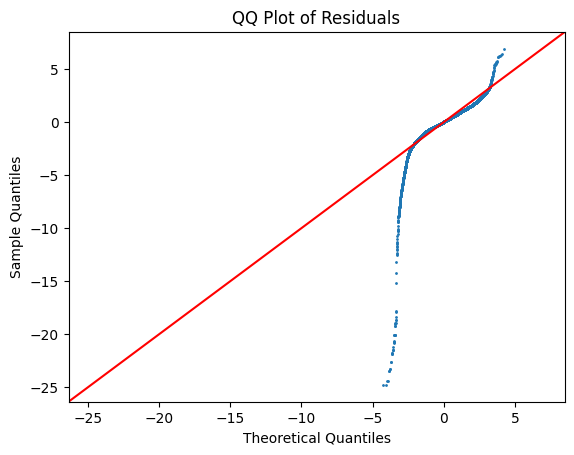

In [47]:
sm.qqplot(ols.get_influence().resid_studentized_internal, line='45', scale=1, markersize=1)
plt.title("QQ Plot of Residuals")
plt.show()

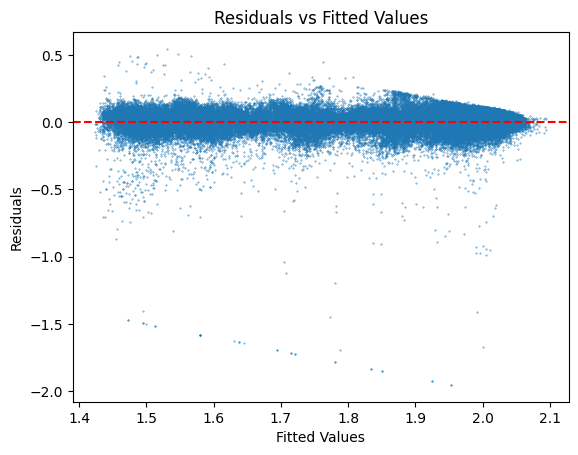

In [48]:
plt.scatter(ols.fittedvalues, ols.resid, s=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [49]:
data_with_snow_day_sum.head()


,Unnamed: 0,Date,Direction,Time,TRAFFIC,PRCP,SNOW,SNWD,SNOW_DAY_SUM,Vehicles,Driver Age,Condition_Code,MorF,DayOfWeek,date,Month
0,0,20140101,1,0,1.531470,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
1,1,20140101,0,0,1.584161,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
2,2,20140101,1,1,1.506488,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
3,3,20140101,0,1,1.626805,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1
4,4,20140101,1,2,1.493881,0.12,1.9,13.0,1.9,0.0,26.0,0.0,0.0,3,2014-01-01,1


In [50]:
data_with_snow_day_sum_dropped = data_with_snow_day_sum.drop(columns={'Date', 'Direction', 'Unnamed: 0', 'PRCP', 'date'})

In [51]:
import umap.umap_ as umap
from sklearn.discriminant_analysis import StandardScaler

reducer = umap.UMAP()
umap_data = data_with_snow_day_sum_dropped
scaler = StandardScaler()
scaled_umap_data = scaler.fit_transform(umap_data)
embedded_data_bp = reducer.fit_transform(scaled_umap_data)

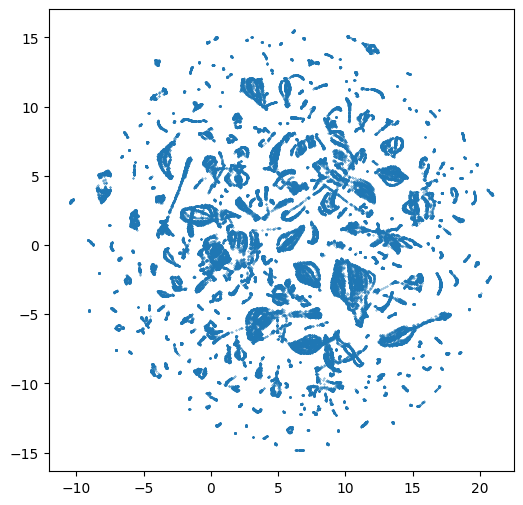

In [52]:
fig = plt.figure(figsize=(6,6))
plt.scatter(embedded_data_bp[:,0], embedded_data_bp[:, 1], s=0.1)
plt.show()

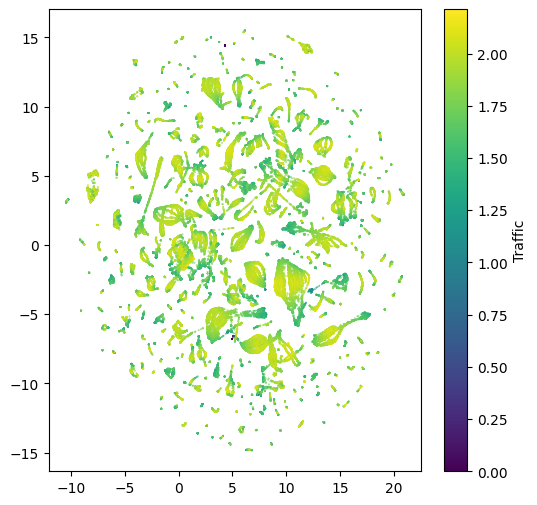

In [53]:
fig = plt.figure(figsize=(6,6))
s = plt.scatter(embedded_data_bp[:,0], embedded_data_bp[:, 1], c=data_with_snow_day_sum_dropped['TRAFFIC'], s=0.1)
plt.colorbar(s, label='Traffic')
plt.show()

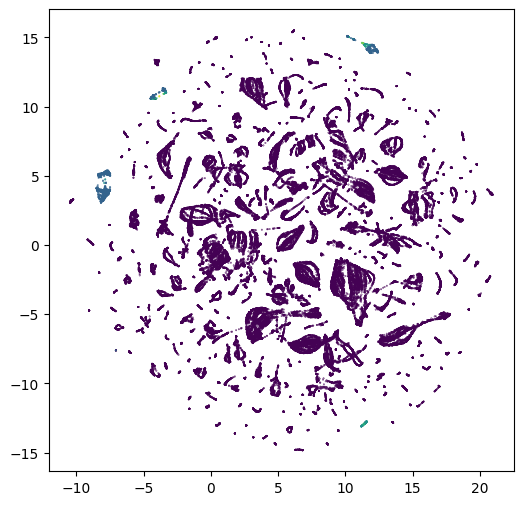

In [54]:
fig = plt.figure(figsize=(6,6))
plt.scatter(embedded_data_bp[:,0], embedded_data_bp[:, 1], c=data_with_snow_day_sum_dropped['Vehicles'], s=0.1)
plt.show()

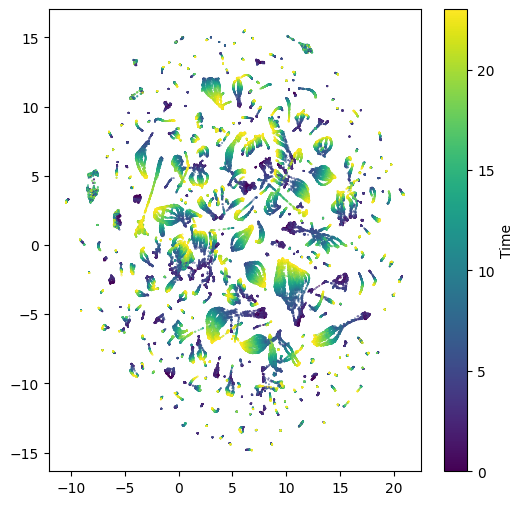

In [55]:
fig = plt.figure(figsize=(6,6))
s = plt.scatter(embedded_data_bp[:,0], embedded_data_bp[:, 1], c=data_with_snow_day_sum_dropped['Time'], s=0.1)
plt.colorbar(s, label='Time')
plt.show()

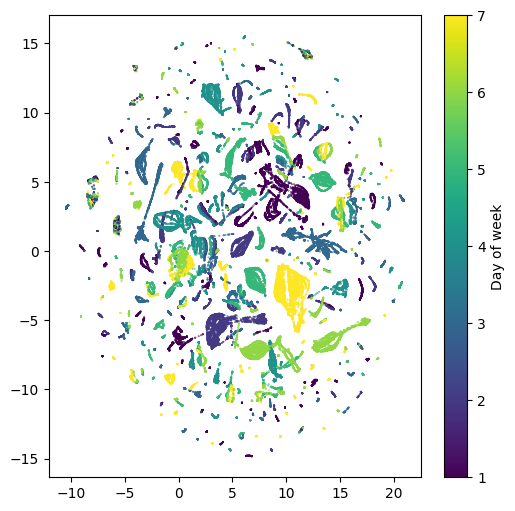

In [56]:
fig = plt.figure(figsize=(6,6))
s = plt.scatter(embedded_data_bp[:,0], embedded_data_bp[:, 1], c=data_with_snow_day_sum_dropped['DayOfWeek'], s=0.1)
plt.colorbar(s, label='Day of week')
plt.show()

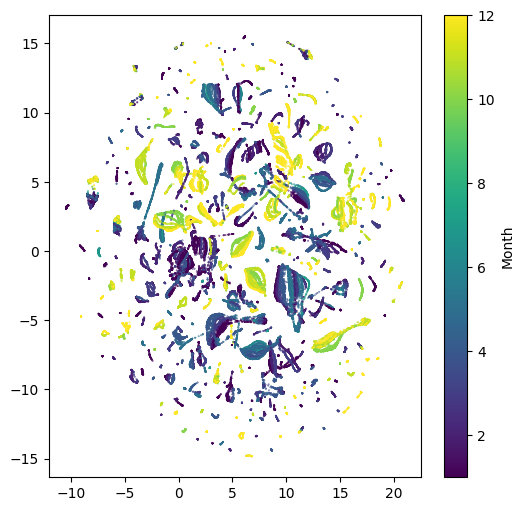

In [57]:
fig = plt.figure(figsize=(6,6))
s = plt.scatter(embedded_data_bp[:,0], embedded_data_bp[:, 1], c=data_with_snow_day_sum_dropped['Month'], s=0.1)
plt.colorbar(s, label='Month')
plt.show()

In [58]:
Month_codots = {
        1: 3, 2:1, 3:2, 4:4, 12: 5, 5:6, 11: 7, 6: 8, 7: 12, 8: 10, 9: 11, 10: 9
    }

data_with_snow_day_sum['WeightedMonth'] = data_with_snow_day_sum['Month'].map(lambda x: Month_codots[x])
data_with_snow_day_sum.head()

C:\Users\wsach\AppData\Local\Temp\ipykernel_27536\48646689.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_with_snow_day_sum['WeightedMonth'] = data_with_snow_day_sum['Month'].map(lambda x: Month_codots[x])


,Unnamed: 0,Date,Direction,Time,TRAFFIC,PRCP,SNOW,SNWD,SNOW_DAY_SUM,Vehicles,Driver Age,Condition_Code,MorF,DayOfWeek,date,Month,WeightedMonth
0,0,20140101,1,0,1.531470,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1,3
1,1,20140101,0,0,1.584161,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1,3
2,2,20140101,1,1,1.506488,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1,3
3,3,20140101,0,1,1.626805,0.12,1.9,13.0,1.9,0.0,0.0,0.0,0.0,3,2014-01-01,1,3
4,4,20140101,1,2,1.493881,0.12,1.9,13.0,1.9,0.0,26.0,0.0,0.0,3,2014-01-01,1,3


In [59]:
ols = smf.ols(
    formula="TRAFFIC ~ C(Time) + C(WeightedMonth, Sum) + C(DayOfWeek) + SNOW_DAY_SUM + Vehicles",
    data=data_with_snow_day_sum
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                TRAFFIC   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                 1.213e+04
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:01:53   Log-Likelihood:             1.0238e+05
No. Observations:               91280   AIC:                        -2.047e+05
Df Residuals:                   91238   BIC:                        -2.043e+05
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [60]:
data_with_snow_day_sum = data_with_snow_day_sum.copy()
data_with_snow_day_sum["log_Vehicles"] = np.log1p(data_with_snow_day_sum["Vehicles"])

data_with_snow_day_sum = data_with_snow_day_sum.copy()
data_with_snow_day_sum['SNOW_DAY_SUM'] = data_with_snow_day_sum['SNOW_DAY_SUM'].map(lambda x: 0.1 if x == 0 else x)

In [61]:
ols_log_predictors = smf.ols(
    formula="TRAFFIC ~ C(Time) + C(WeightedMonth, Sum) + C(DayOfWeek) + SNOW_DAY_SUM + log_Vehicles",
    data=data_with_snow_day_sum
).fit()

print(ols_log_predictors.summary())

                            OLS Regression Results                            
Dep. Variable:                TRAFFIC   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                 1.213e+04
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        13:01:53   Log-Likelihood:             1.0238e+05
No. Observations:               91280   AIC:                        -2.047e+05
Df Residuals:                   91238   BIC:                        -2.043e+05
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [62]:
print(ols_log_predictors.condition_number)

181.88286923854173
